##### Feladat (Példatár 1.11)

Az alábbi keresztmetszet terhelése az $M = 5 ~\mathrm{kNm}$  hajlítónyomatéki igénybevétel az ábrán látható módon. Határozzuk meg az $A$ pontban ébredő normálfeszültség nagyságát!

<img src="img/01.jpg" alt="Feladat" width=250px>

##### Csomagok importálása

In [1]:
import numpy as np # Numerikus számítások
import matplotlib.pyplot as plt # Ábrázolás
plt.rcParams['mathtext.fontset'] = 'cm' # Betűtípus az ábrákon
plt.rcParams['font.family'] = 'serif' # Betűtípus az ábrákon
plt.rcParams['font.serif'] = ['cmr10'] # Betűtípus az ábrákon
plt.rcParams['axes.formatter.use_mathtext'] = True # Betűtípus az ábrákon
plt.rcParams['axes.unicode_minus'] = False # Betűtípus az ábrákon
from IPython.display import display, Math, Latex # Szép kimenet Jupyter notebookban
import sympy as sp # Szimbólikus számítások
from sympy import latex # Szép kimenet Jupyter notebookban
sp.init_printing() # Szép kimenet Jupyter notebookban

##### Adatok

In [2]:
M = 5 # kNm
a_1 = 50 # mm
b_1 = 400 # mm
a_2 = 25 # mm
b_2 = 300 # mm

# Átváltás N, mm, MPa rendszerbe
M = M * 10**6 # Nmm

##### Másodrendű nyomaték a hajlítás tengelyére

In [3]:
I_z = (a_1 * b_1**3) / 12 + 2 * (a_2 * b_2**3) / 12
display(Math(rf'I_z = {latex(round(I_z,3))} ~\mathrm{{mm^4}}'))

<IPython.core.display.Math object>

##### Navier-féle képlet

In [4]:
# Navier-képlet
def sigma(y):
    return -(M/I_z) * y

# Feszültség a felső szálban
sigma_top = sigma(b_1/2)

# Feszültség az alsó szálban
sigma_bottom = sigma(-b_1/2)

# Feszültség az 'A' pontban
sigma_A = sigma(-b_2/2)
display(Math(rf'\sigma_A = {latex(round(sigma_A,3))} ~\mathrm{{MPa}}'))

<IPython.core.display.Math object>

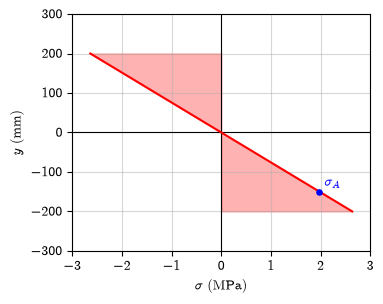

In [5]:
y = [b_1/2, -b_1/2]
x = [sigma_top, sigma_bottom]

plt.figure(figsize=(10/2.54, 8/2.54))
plt.plot(x, y, color='red', zorder=5)
plt.fill_betweenx(y, x, 0, color='red', alpha=0.3)
plt.scatter(sigma_A, -b_2/2, color='blue', s = 14, zorder=6)
plt.text(sigma_A*1.05, -b_2/2*0.95, r'$\sigma_A$', fontsize=10, ha='left', va='bottom', color='blue')
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel(r'$\sigma ~ \mathrm{(MPa)}$')
plt.ylabel(r'$y ~ \mathrm{(mm)}$')
plt.grid(True, alpha=0.5)
plt.xlim(-3, 3)
plt.ylim(-300, 300)
plt.tight_layout()
plt.savefig('normal_feszultseg.pdf')